步骤1/6: 加载所有数据和模型...
测试集最大径流量样本索引: 173, 流量值: 7760.0
成功加载LSTM模型: ./models/lstm/lstm_best_model.pth
测试集最大径流量样本ANN预测值: 6205.150763244985
测试集最大径流量样本LSTM预测值: 6732.91259765625
步骤2/6: 计算LR和XGB的特征重要性...
正在计算XGB的特征重要性...
步骤3/6: 加载或计算ANN的SHAP值...
加载已保存的SHAP结果: combined_analysis_results\ann_shap_results.pkl
步骤4/6: 加载或计算LSTM的SHAP值...
加载已保存的SHAP结果: combined_analysis_results\lstm_shap_results.pkl
步骤5/6: 分析SHAP特征重要性...
步骤6/6: 生成3x2组合分析图表...


G:\Anaconda\envs\torch\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


3x2组合分析图表已保存至: combined_analysis_results\plots\3x2_combined_feature_analysis.png


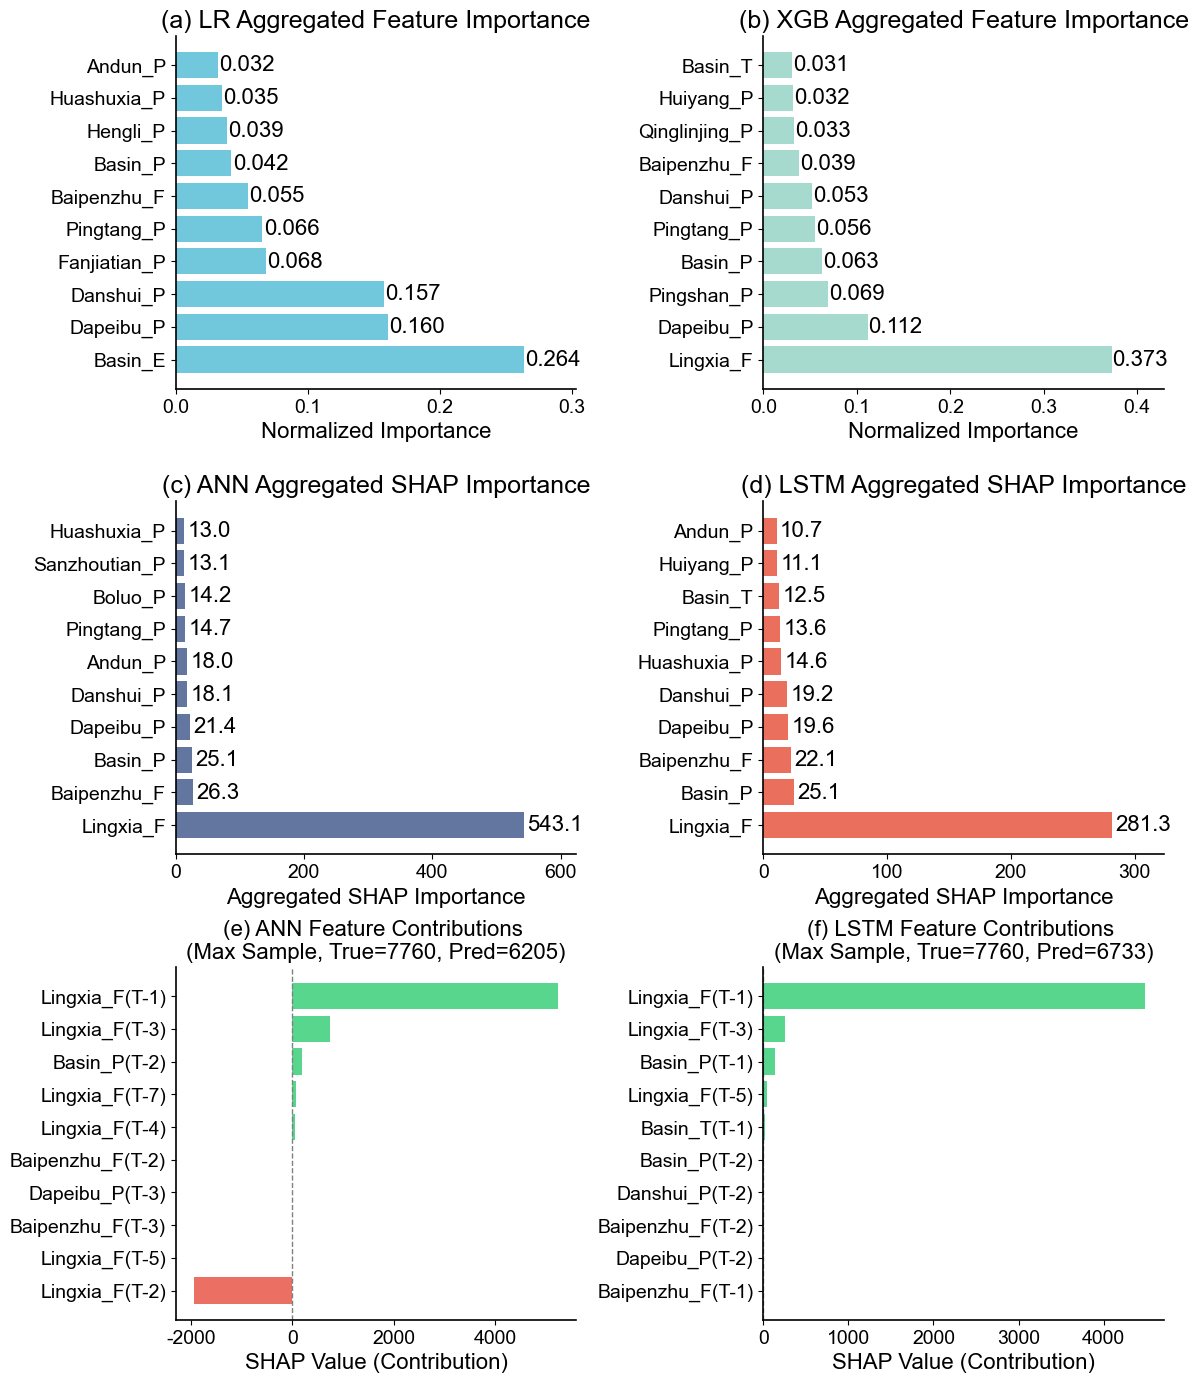

所有模型的特征重要性和SHAP分析已完成！
所有结果已保存至: combined_analysis_results

关键指标汇总

【LR Top 10 特征重要性】
  Basin_E             : 0.2636
  Dapeibu_P           : 0.1603
  Danshui_P           : 0.1575
  Fanjiatian_P        : 0.0680
  Pingtang_P          : 0.0655
  Baipenzhu_F         : 0.0547
  Basin_P             : 0.0421
  Hengli_P            : 0.0386
  Huashuxia_P         : 0.0351
  Andun_P             : 0.0317

【XGB Top 10 特征重要性】
  Lingxia_F           : 0.3726
  Dapeibu_P           : 0.1116
  Pingshan_P          : 0.0691
  Basin_P             : 0.0633
  Pingtang_P          : 0.0555
  Danshui_P           : 0.0526
  Baipenzhu_F         : 0.0386
  Qinglinjing_P       : 0.0325
  Huiyang_P           : 0.0320
  Basin_T             : 0.0306

【ANN SHAP Top 10 特征重要性】
  Lingxia_F           : 543.11
  Baipenzhu_F         : 26.30
  Basin_P             : 25.07
  Dapeibu_P           : 21.39
  Danshui_P           : 18.14
  Andun_P             : 18.05
  Pingtang_P          : 14.71
  Boluo_P             : 14.20
  Sanzhou

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import re
import shap
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from matplotlib.colors import LinearSegmentedColormap

# 设置全局字体和绘图参数
plt.rcParams["font.family"] = ["Arial", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["lines.linewidth"] = 2.0
plt.rcParams["patch.edgecolor"] = "white"
plt.rcParams["patch.linewidth"] = 0.8

# 模型颜色配置（Nature配色）
MODEL_COLORS = {
    "LR": "#4DBBD5",
    "XGB": "#91D1C2",
    "ANN": "#3C5488",
    "LSTM": "#E64B35"  # LSTM使用砖红色
}

# 特征映射：中文 -> 英文
FEATURE_MAPPING = {
    '岭下站流量': 'Lingxia_F',
    '白盆珠出库流量': 'Baipenzhu_F',
    '大陂布': 'Dapeibu_P',
    '安墩': 'Andun_P',
    '平山': 'Pingshan_P',
    '平潭': 'Pingtang_P',
    '惠阳': 'Huiyang_P',
    '横沥': 'Hengli_P',
    '洋潭': 'Yangtan_P',
    '淡水': 'Danshui_P',
    '清林径': 'Qinglinjing_P',
    '花树下': 'Huashuxia_P',
    '范家田': 'Fanjiatian_P',
    '上坪': 'Shangping_P',
    '三洲田': 'Sanzhoutian_P',
    '博罗': 'Boluo_P',
    '博罗_T': 'Basin_T',
    '博罗_P': 'Basin_P',
    '博罗_E': 'Basin_E'
}

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------------------------------
# LSTM模型定义（与训练时一致）
# ------------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64], dropout=0.2, bidirectional=False):
        super(LSTMModel, self).__init__()
        
        self.num_directions = 2 if bidirectional else 1
        
        self.lstm1 = nn.LSTM(input_size, hidden_sizes[0], batch_first=True, bidirectional=bidirectional)
        self.dropout1 = nn.Dropout(dropout)
        
        lstm1_out = hidden_sizes[0] * self.num_directions
        self.lstm2 = nn.LSTM(lstm1_out, hidden_sizes[1], batch_first=True, bidirectional=bidirectional)
        self.dropout2 = nn.Dropout(dropout)
        
        lstm2_out = hidden_sizes[1] * self.num_directions
        self.fc1 = nn.Linear(lstm2_out, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out = out[:, -1, :]
        out = torch.relu(self.bn1(self.fc1(out)))
        out = self.fc2(out)
        return out

# ------------------------------
# 数据和模型加载函数
# ------------------------------
def load_all_data_and_models(train_path='../数据/train_data.csv', test_path='../数据/test_data.csv', 
                             model_dir='./models/', lstm_dir='./models/lstm/'):
    """加载所有数据和模型（LR、XGB、ANN和LSTM）"""
    # 加载数据
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)
    
    # 从测试集中找出最大径流量样本
    test_flow = test_data['博罗站流量']
    max_test_flow_idx = test_flow.idxmax()
    max_test_flow_value = test_flow[max_test_flow_idx]
    print(f"测试集最大径流量样本索引: {max_test_flow_idx}, 流量值: {max_test_flow_value}")
    
    # 分离特征和目标变量
    X_train = train_data.drop(['博罗站流量', 'date'], axis=1, errors='ignore')
    y_train = train_data['博罗站流量']
    X_test = test_data.drop(['博罗站流量', 'date'], axis=1, errors='ignore')
    y_test = test_data['博罗站流量']
    
    # 提取测试集最大样本的特征和真实值
    max_test_sample_features = X_test.iloc[max_test_flow_idx]
    max_test_sample_true_value = y_test[max_test_flow_idx]
    
    # 划分样本集用于SHAP分析
    X_sample, _, _, _ = train_test_split(
        X_train, y_train, 
        test_size=0.9,
        random_state=42,
        stratify=None
    )
    
    # 加载传统ML模型
    lr_model = joblib.load(os.path.join(model_dir, 'LR_best_model.pkl'))
    xgb_model = joblib.load(os.path.join(model_dir, 'XGB_best_model.pkl'))
    ann_model = joblib.load(os.path.join(model_dir, 'ANN_best_model.pkl'))
    
    # 加载LSTM模型和scaler
    lstm_model = None
    scaler_X = None
    scaler_y = None
    
    lstm_model_path = os.path.join(lstm_dir, 'lstm_best_model.pth')
    scaler_X_path = os.path.join(lstm_dir, 'scaler_X.pkl')
    scaler_y_path = os.path.join(lstm_dir, 'scaler_y.pkl')
    
    if os.path.exists(lstm_model_path):
        # 加载scalers
        scaler_X = joblib.load(scaler_X_path)
        scaler_y = joblib.load(scaler_y_path)
        
        # 确定LSTM输入参数
        n_lag = 7
        n_features_per_lag = X_train.shape[1] // n_lag
        
        # 加载LSTM模型
        lstm_model = LSTMModel(
            input_size=n_features_per_lag,
            hidden_sizes=[128, 64],
            dropout=0.2,
            bidirectional=False
        ).to(device)
        lstm_model.load_state_dict(torch.load(lstm_model_path, map_location=device))
        lstm_model.eval()
        print(f"成功加载LSTM模型: {lstm_model_path}")
    else:
        print(f"警告: LSTM模型文件不存在: {lstm_model_path}")
    
    # 计算ANN对最大样本的预测值
    max_test_sample_pred_ann = ann_model.predict(
        max_test_sample_features.values.reshape(1, -1)
    )[0]
    print(f"测试集最大径流量样本ANN预测值: {max_test_sample_pred_ann}")
    
    # 计算LSTM对最大样本的预测值
    max_test_sample_pred_lstm = None
    if lstm_model is not None:
        X_max_scaled = scaler_X.transform(max_test_sample_features.values.reshape(1, -1))
        X_max_reshaped = X_max_scaled.reshape(1, n_lag, n_features_per_lag).astype(np.float32)
        X_max_tensor = torch.FloatTensor(X_max_reshaped).to(device)
        with torch.no_grad():
            pred_scaled = lstm_model(X_max_tensor).cpu().numpy().flatten()
        max_test_sample_pred_lstm = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()[0]
        print(f"测试集最大径流量样本LSTM预测值: {max_test_sample_pred_lstm}")
    
    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_sample': X_sample,
        'feature_names': X_train.columns.tolist(),
        'models': {
            'LR': lr_model,
            'XGB': xgb_model,
            'ANN': ann_model,
            'LSTM': lstm_model
        },
        'scaler_X': scaler_X,
        'scaler_y': scaler_y,
        'n_lag': 7,
        'n_features_per_lag': X_train.shape[1] // 7,
        'max_test_flow_idx': max_test_flow_idx,
        'max_test_flow_value': max_test_flow_value,
        'max_test_sample_pred_ann': max_test_sample_pred_ann,
        'max_test_sample_pred_lstm': max_test_sample_pred_lstm,
        'max_test_sample_features': max_test_sample_features
    }

# ------------------------------
# 特征名称处理函数
# ------------------------------
def extract_base_feature(feature_name):
    """从带lag的特征名中提取基础特征名"""
    return re.sub(r'_?lag_?\d+$', '', feature_name)

def translate_feature_name(feature):
    """将单个中文特征名翻译为英文"""
    base_feature = extract_base_feature(feature)
    
    if base_feature in FEATURE_MAPPING:
        english_base = FEATURE_MAPPING[base_feature]
        lag_match = re.search(r'_?lag_?(\d+)', feature)
        if lag_match:
            return f"{english_base}_lag{lag_match.group(1)}"
        else:
            return english_base
    return feature

def translate_feature_names(features):
    """将中文特征名列表翻译为英文"""
    return [translate_feature_name(f) for f in features]

# ------------------------------
# 特征重要性计算函数
# ------------------------------
def calculate_feature_importance(data):
    """计算LR和XGB两种模型的特征重要性"""
    feature_names = data['feature_names']
    models = data['models']
    
    importance_results = {}
    
    # 1. 线性回归 (LR) - 使用系数绝对值作为重要性
    lr_importance = np.abs(models['LR'].coef_)
    importance_results['LR'] = pd.DataFrame({
        'feature': feature_names,
        'importance': lr_importance / np.sum(lr_importance)  # 归一化
    }).sort_values('importance', ascending=False)
    
    # 2. XGBoost (XGB) - 使用内置特征重要性
    print("正在计算XGB的特征重要性...")
    xgb_importance = models['XGB'].feature_importances_
    importance_results['XGB'] = pd.DataFrame({
        'feature': feature_names,
        'importance': xgb_importance / np.sum(xgb_importance)  # 归一化
    }).sort_values('importance', ascending=False)
    
    return importance_results

def aggregate_lag_importance(importance_df):
    """将相同基础特征不同lag天数的重要性合并"""
    importance_df['base_feature'] = importance_df['feature'].apply(extract_base_feature)
    aggregated_df = importance_df.groupby('base_feature')['importance'].sum().reset_index()
    aggregated_df['base_feature_english'] = translate_feature_names(aggregated_df['base_feature'])
    aggregated_df['importance'] = aggregated_df['importance'] / aggregated_df['importance'].sum()
    return aggregated_df.sort_values('importance', ascending=False)
    
# ------------------------------
# SHAP分析函数（ANN）
# ------------------------------
def calculate_shap_values_ann(data, use_gpu=False, save_path=None):
    """计算ANN模型的SHAP值"""
    model = data['models']['ANN']
    X_sample = data['X_sample']
    feature_names = data['feature_names']
    
    english_features = translate_feature_names(feature_names)
    X_sample = X_sample.copy()
    X_sample.columns = english_features
    
    print("初始化ANN SHAP解释器...")
    explainer = shap.KernelExplainer(
        model.predict, 
        X_sample.sample(min(100, len(X_sample)), random_state=42)
    )
    
    print("计算ANN SHAP值...")
    X_test_english = data['X_test'].copy()
    X_test_english.columns = english_features
    shap_values = explainer.shap_values(
        X_test_english,
        nsamples=200,
        l1_reg="auto"
    )
    
    results = {
        'shap_values': shap_values,
        'X_test': X_test_english,
        'feature_names': english_features,
        'expected_value': explainer.expected_value
    }
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        joblib.dump(results, save_path)
        print(f"ANN SHAP结果已保存至: {save_path}")
    
    return results

# ------------------------------
# SHAP分析函数（LSTM）
# ------------------------------
def calculate_shap_values_lstm(data, use_gpu=False, save_path=None):
    """计算LSTM模型的SHAP值"""
    lstm_model = data['models']['LSTM']
    if lstm_model is None:
        print("LSTM模型未加载，跳过SHAP计算")
        return None
    
    scaler_X = data['scaler_X']
    scaler_y = data['scaler_y']
    n_lag = data['n_lag']
    n_features_per_lag = data['n_features_per_lag']
    feature_names = data['feature_names']
    
    english_features = translate_feature_names(feature_names)
    
    # 准备数据
    X_test = data['X_test'].values
    X_test_scaled = scaler_X.transform(X_test)
    X_test_reshaped = X_test_scaled.reshape(-1, n_lag, n_features_per_lag).astype(np.float32)
    
    # 创建LSTM预测包装函数
    def lstm_predict(X_flat):
        """将扁平化输入转换为LSTM格式并预测"""
        X_scaled = scaler_X.transform(X_flat)
        X_reshaped = X_scaled.reshape(-1, n_lag, n_features_per_lag).astype(np.float32)
        X_tensor = torch.FloatTensor(X_reshaped).to(device)
        lstm_model.eval()
        with torch.no_grad():
            pred_scaled = lstm_model(X_tensor).cpu().numpy().flatten()
        pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
        return pred
    
    # 背景数据
    X_sample = data['X_sample'].values
    background_idx = np.random.choice(len(X_sample), min(100, len(X_sample)), replace=False)
    background = X_sample[background_idx]
    
    print("初始化LSTM SHAP解释器...")
    explainer = shap.KernelExplainer(lstm_predict, background)
    
    print("计算LSTM SHAP值（这可能需要较长时间）...")
    # 为节省时间，只计算部分测试样本的SHAP值
    test_sample_idx = np.random.choice(len(X_test), min(500, len(X_test)), replace=False)
    test_sample_idx = np.sort(test_sample_idx)
    
    # 确保包含最大流量样本
    max_idx = data['max_test_flow_idx']
    if max_idx not in test_sample_idx:
        test_sample_idx = np.append(test_sample_idx, max_idx)
        test_sample_idx = np.sort(test_sample_idx)
    
    X_test_subset = X_test[test_sample_idx]
    
    shap_values = explainer.shap_values(
        X_test_subset,
        nsamples=100,
        l1_reg="auto"
    )
    
    results = {
        'shap_values': shap_values,
        'X_test': X_test_subset,
        'X_test_idx': test_sample_idx,
        'feature_names': english_features,
        'expected_value': explainer.expected_value,
        'max_idx_in_subset': np.where(test_sample_idx == max_idx)[0][0]
    }
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        joblib.dump(results, save_path)
        print(f"LSTM SHAP结果已保存至: {save_path}")
    
    return results

def load_shap_results(load_path):
    """加载已保存的SHAP计算结果"""
    if not os.path.exists(load_path):
        return None
    if os.path.getsize(load_path) < 1024:
        print(f"检测到可能损坏的SHAP结果文件: {load_path}")
        return None
    try:
        print(f"加载已保存的SHAP结果: {load_path}")
        return joblib.load(load_path)
    except Exception as e:
        print(f"加载SHAP结果失败: {str(e)}")
        return None

def analyze_shap_importance(shap_results, output_dir='shap_results', model_name='ANN'):
    """分析SHAP特征重要性"""
    os.makedirs(output_dir, exist_ok=True)
    
    feature_importance = np.mean(np.abs(shap_results['shap_values']), axis=0)
    
    importance_df = pd.DataFrame({
        'feature': shap_results['feature_names'],
        'shap_importance': feature_importance
    }).sort_values('shap_importance', ascending=False)
    
    importance_df.to_csv(os.path.join(output_dir, f'{model_name}_shap_feature_importance.csv'), index=False)
    
    importance_df['base_feature'] = importance_df['feature'].apply(
        lambda x: re.sub(r'_lag\d+$', '', x)
    )
    aggregated_importance = importance_df.groupby('base_feature')['shap_importance'].sum().reset_index()
    aggregated_importance = aggregated_importance.sort_values('shap_importance', ascending=False)
    
    aggregated_importance.to_csv(os.path.join(output_dir, f'{model_name}_shap_aggregated_importance.csv'), index=False)
    
    return {
        'raw_importance': importance_df,
        'aggregated_importance': aggregated_importance
    }

# ------------------------------
# 主绘图函数 - 3x2组合图
# ------------------------------
def plot_3x2_combined(data, importance_results, shap_results_ann, shap_importance_ann,
                     shap_results_lstm, shap_importance_lstm,
                     output_dir='combined_plots', top_n=10):
    """生成3x2组合图"""
    os.makedirs(output_dir, exist_ok=True)
    
    max_test_idx = data['max_test_flow_idx']
    max_test_true_value = data['max_test_flow_value']
    max_test_pred_ann = data['max_test_sample_pred_ann']
    max_test_pred_lstm = data['max_test_sample_pred_lstm']
    
    # 创建3x2子图
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    
    # ------------------------------
    # 1. (a) LR特征重要性
    # ------------------------------
    ax1 = axes[0, 0]
    lr_aggregated = aggregate_lag_importance(importance_results['LR']).head(top_n)
    
    y_pos = np.arange(len(lr_aggregated))
    bars = ax1.barh(y_pos, lr_aggregated['importance'][::-1], 
                   color=MODEL_COLORS['LR'], alpha=0.8)
    
    for bar in bars:
        width = bar.get_width()
        ax1.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=16)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(lr_aggregated['base_feature_english'][::-1], fontsize=14)
    ax1.set_xlabel('Normalized Importance', fontsize=16)
    ax1.set_title('(a) LR Aggregated Feature Importance', fontsize=18)
    ax1.invert_yaxis()
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlim(0, max(lr_aggregated['importance']) * 1.15)
    
    # ------------------------------
    # 2. (b) XGB特征重要性
    # ------------------------------
    ax2 = axes[0, 1]
    xgb_aggregated = aggregate_lag_importance(importance_results['XGB']).head(top_n)
    
    y_pos = np.arange(len(xgb_aggregated))
    bars = ax2.barh(y_pos, xgb_aggregated['importance'][::-1], 
                   color=MODEL_COLORS['XGB'], alpha=0.8)
    
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=16)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(xgb_aggregated['base_feature_english'][::-1], fontsize=14)
    ax2.set_xlabel('Normalized Importance', fontsize=16)
    ax2.set_title('(b) XGB Aggregated Feature Importance', fontsize=18)
    ax2.invert_yaxis()
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xlim(0, max(xgb_aggregated['importance']) * 1.15)
    
    # ------------------------------
    # 3. (c) ANN聚合SHAP重要性
    # ------------------------------
    ax3 = axes[1, 0]
    ann_aggregated = shap_importance_ann['aggregated_importance'].head(top_n)
    
    y_pos = np.arange(len(ann_aggregated))
    bars = ax3.barh(y_pos, ann_aggregated['shap_importance'][::-1], 
                   color=MODEL_COLORS['ANN'], alpha=0.8)
    
    for bar in bars:
        width = bar.get_width()
        ax3.text(width + ann_aggregated['shap_importance'].max()*0.01, 
                bar.get_y() + bar.get_height()/2,
                f'{width:.1f}', ha='left', va='center', fontsize=16)
    
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(ann_aggregated['base_feature'][::-1], fontsize=14)
    ax3.set_xlabel('Aggregated SHAP Importance', fontsize=16)
    ax3.set_title('(c) ANN Aggregated SHAP Importance', fontsize=18)
    ax3.invert_yaxis()
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.set_xlim(0, max(ann_aggregated['shap_importance']) * 1.15)
    
    # ------------------------------
    # 4. (d) LSTM聚合SHAP重要性
    # ------------------------------
    ax4 = axes[1, 1]
    if shap_importance_lstm is not None:
        lstm_aggregated = shap_importance_lstm['aggregated_importance'].head(top_n)
        
        y_pos = np.arange(len(lstm_aggregated))
        bars = ax4.barh(y_pos, lstm_aggregated['shap_importance'][::-1], 
                       color=MODEL_COLORS['LSTM'], alpha=0.8)
        
        for bar in bars:
            width = bar.get_width()
            ax4.text(width + lstm_aggregated['shap_importance'].max()*0.01, 
                    bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}', ha='left', va='center', fontsize=16)
        
        ax4.set_yticks(y_pos)
        ax4.set_yticklabels(lstm_aggregated['base_feature'][::-1], fontsize=14)
        ax4.set_xlabel('Aggregated SHAP Importance', fontsize=16)
        ax4.set_title('(d) LSTM Aggregated SHAP Importance', fontsize=18)
        ax4.invert_yaxis()
        ax4.spines['top'].set_visible(False)
        ax4.spines['right'].set_visible(False)
        ax4.set_xlim(0, max(lstm_aggregated['shap_importance']) * 1.15)
    else:
        ax4.text(0.5, 0.5, 'LSTM SHAP Not Available', ha='center', va='center', fontsize=16)
        ax4.set_title('(d) LSTM Aggregated SHAP Importance', fontsize=18)
    
    # ------------------------------
    # 5. (e) ANN最大样本贡献图
    # ------------------------------
    ax5 = axes[2, 0]
    shap_values_ann = shap_results_ann['shap_values']
    feature_names_ann = shap_results_ann['feature_names']
    expected_value_ann = shap_results_ann['expected_value']
    
    sorted_idx_ann = np.argsort(np.mean(np.abs(shap_values_ann), axis=0))[::-1]
    top_features_idx_ann = sorted_idx_ann[:top_n]
    top_features_ann = [feature_names_ann[i] for i in top_features_idx_ann]
    
    sample_shap_ann = shap_values_ann[max_test_idx, top_features_idx_ann]
    sorted_idx = np.argsort(sample_shap_ann)
    sorted_shap_ann = sample_shap_ann[sorted_idx]
    sorted_features_ann = [top_features_ann[i] for i in sorted_idx]

        # ========== 新增：将lag转换为T-n格式 ==========
    def convert_lag_to_t(feature_name):
        """将lag7转换为T-1, lag6转换为T-2, 以此类推"""
        lag_match = re.search(r'_lag(\d+)$', str(feature_name))  # 确保是字符串
        if lag_match:
            lag_num = int(lag_match.group(1))
            t_num = 8 - lag_num
            return re.sub(r'_lag\d+$', f'(T-{t_num})', feature_name)
        return feature_name
    
    sorted_features_ann_display = [convert_lag_to_t(f) for f in sorted_features_ann]
    # ========== 新增结束 ==========
    
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sorted_shap_ann]
    ax5.barh(range(len(sorted_shap_ann)), sorted_shap_ann, color=colors, alpha=0.8)
    
    ax5.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    
    ax5.set_yticks(range(len(sorted_shap_ann)))
    ax5.set_yticklabels(sorted_features_ann_display, fontsize=14)
    ax5.set_xlabel('SHAP Value (Contribution)', fontsize=16)
    ax5.set_title(f'(e) ANN Feature Contributions \n(Max Sample, True={max_test_true_value:.0f}, Pred={max_test_pred_ann:.0f})', fontsize=16)
    ax5.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
    
    # ------------------------------
    # 6. (f) LSTM最大样本贡献图
    # ------------------------------
    ax6 = axes[2, 1]
    if shap_results_lstm is not None:
        shap_values_lstm = shap_results_lstm['shap_values']
        feature_names_lstm = shap_results_lstm['feature_names']
        max_idx_in_subset = shap_results_lstm['max_idx_in_subset']
        
        sorted_idx_lstm = np.argsort(np.mean(np.abs(shap_values_lstm), axis=0))[::-1]
        top_features_idx_lstm = sorted_idx_lstm[:top_n]
        top_features_lstm = [feature_names_lstm[i] for i in top_features_idx_lstm]
        
        sample_shap_lstm = shap_values_lstm[max_idx_in_subset, top_features_idx_lstm]
        sorted_idx = np.argsort(sample_shap_lstm)
        sorted_shap_lstm = sample_shap_lstm[sorted_idx]
        sorted_features_lstm = [top_features_lstm[i] for i in sorted_idx]
        
        # ========== 新增：将lag转换为T-n格式 ==========
        sorted_features_lstm_display = [convert_lag_to_t(f) for f in sorted_features_lstm]
        # ========== 新增结束 ==========

        
        colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sorted_shap_lstm]
        ax6.barh(range(len(sorted_shap_lstm)), sorted_shap_lstm, color=colors, alpha=0.8)
        
        ax6.axvline(x=0, color='gray', linestyle='--', linewidth=1)
        
        ax6.set_yticks(range(len(sorted_shap_lstm)))
        ax6.set_yticklabels(sorted_features_lstm_display, fontsize=14)
        ax6.set_xlabel('SHAP Value (Contribution)', fontsize=16)
        ax6.set_title(f'(f) LSTM Feature Contributions \n(Max Sample, True={max_test_true_value:.0f}, Pred={max_test_pred_lstm:.0f})', fontsize=16)
        ax6.spines['top'].set_visible(False)
        ax6.spines['right'].set_visible(False)
    else:
        ax6.text(0.5, 0.5, 'LSTM SHAP Not Available', ha='center', va='center', fontsize=16)
        ax6.set_title('(f) LSTM Feature Contributions', fontsize=18)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.97, hspace=0.32)
    
    output_path = os.path.join(output_dir, '3x2_combined_feature_analysis.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"3x2组合分析图表已保存至: {output_path}")
    plt.show()
    
    return output_path

# ------------------------------
# 主函数
# ------------------------------
def main():
    # 配置参数
    train_path = '../数据/train_data.csv'
    test_path = '../数据/test_data.csv'
    model_dir = './models/'
    lstm_dir = './models/lstm/'
    output_root = 'combined_analysis_results'
    shap_ann_save_path = os.path.join(output_root, 'ann_shap_results.pkl')
    shap_lstm_save_path = os.path.join(output_root, 'lstm_shap_results.pkl')
    top_n_features = 10
    
    os.makedirs(output_root, exist_ok=True)
    
    # 加载数据和模型
    print("步骤1/6: 加载所有数据和模型...")
    data = load_all_data_and_models(
        train_path=train_path,
        test_path=test_path,
        model_dir=model_dir,
        lstm_dir=lstm_dir
    )
    
    # 计算LR和XGB特征重要性
    print("步骤2/6: 计算LR和XGB的特征重要性...")
    importance_results = calculate_feature_importance(data)
    
    # ANN SHAP分析
    print("步骤3/6: 加载或计算ANN的SHAP值...")
    shap_results_ann = load_shap_results(shap_ann_save_path)
    if shap_results_ann is None:
        shap_results_ann = calculate_shap_values_ann(data, save_path=shap_ann_save_path)
    
    # LSTM SHAP分析
    print("步骤4/6: 加载或计算LSTM的SHAP值...")
    shap_results_lstm = load_shap_results(shap_lstm_save_path)
    if shap_results_lstm is None and data['models']['LSTM'] is not None:
        shap_results_lstm = calculate_shap_values_lstm(data, save_path=shap_lstm_save_path)
    
    # 分析SHAP重要性
    print("步骤5/6: 分析SHAP特征重要性...")
    shap_importance_ann = analyze_shap_importance(
        shap_results_ann, 
        output_dir=os.path.join(output_root, 'shap_importance'),
        model_name='ANN'
    )
    
    shap_importance_lstm = None
    if shap_results_lstm is not None:
        shap_importance_lstm = analyze_shap_importance(
            shap_results_lstm, 
            output_dir=os.path.join(output_root, 'shap_importance'),
            model_name='LSTM'
        )
    
    # 生成3x2组合图
    print("步骤6/6: 生成3x2组合分析图表...")
    plot_3x2_combined(
        data,
        importance_results,
        shap_results_ann,
        shap_importance_ann,
        shap_results_lstm,
        shap_importance_lstm,
        output_dir=os.path.join(output_root, 'plots'),
        top_n=top_n_features
    )
    
    print("所有模型的特征重要性和SHAP分析已完成！")
    print(f"所有结果已保存至: {output_root}")

    # ========== 新增：打印关键指标 ==========
    print("\n" + "="*80)
    print("关键指标汇总")
    print("="*80)
    
    # 1. LR Top 10 特征重要性
    print("\n【LR Top 10 特征重要性】")
    lr_agg = aggregate_lag_importance(importance_results['LR']).head(10)
    for i, row in lr_agg.iterrows():
        print(f"  {row['base_feature_english']:<20}: {row['importance']:.4f}")
    
    # 2. XGB Top 10 特征重要性
    print("\n【XGB Top 10 特征重要性】")
    xgb_agg = aggregate_lag_importance(importance_results['XGB']).head(10)
    for i, row in xgb_agg.iterrows():
        print(f"  {row['base_feature_english']:<20}: {row['importance']:.4f}")
    
    # 3. ANN SHAP Top 10 特征重要性
    print("\n【ANN SHAP Top 10 特征重要性】")
    ann_agg = shap_importance_ann['aggregated_importance'].head(10)
    for i, row in ann_agg.iterrows():
        print(f"  {row['base_feature']:<20}: {row['shap_importance']:.2f}")
    
    # 4. LSTM SHAP Top 10 特征重要性
    if shap_importance_lstm is not None:
        print("\n【LSTM SHAP Top 10 特征重要性】")
        lstm_agg = shap_importance_lstm['aggregated_importance'].head(10)
        for i, row in lstm_agg.iterrows():
            print(f"  {row['base_feature']:<20}: {row['shap_importance']:.2f}")
    
    # 6. ANN最大样本Top 10特征SHAP贡献（图e）
    print("\n【ANN最大样本 Top 10 特征SHAP贡献 (图e)】")
    max_test_idx = data['max_test_flow_idx']
    shap_values_ann = shap_results_ann['shap_values']
    feature_names_ann = shap_results_ann['feature_names']
    
    sorted_idx_ann = np.argsort(np.mean(np.abs(shap_values_ann), axis=0))[::-1]
    top_features_idx_ann = sorted_idx_ann[:10]
    
    def convert_lag_to_t(feature_name):
        lag_match = re.search(r'_lag(\d+)$', str(feature_name))
        if lag_match:
            lag_num = int(lag_match.group(1))
            t_num = 8 - lag_num
            return re.sub(r'_lag\d+$', f'(T-{t_num})', feature_name)
        return feature_name
    
    print(f"  {'特征名':<25} {'SHAP贡献值':<15} {'方向':<10}")
    print(f"  {'-'*50}")
    for idx in top_features_idx_ann:
        feat_name = convert_lag_to_t(feature_names_ann[idx])
        shap_val = shap_values_ann[max_test_idx, idx]
        direction = "正向↑" if shap_val > 0 else "负向↓"
        print(f"  {feat_name:<25} {shap_val:<15.2f} {direction:<10}")
    
    # 7. LSTM最大样本Top 10特征SHAP贡献（图f）
    if shap_results_lstm is not None:
        print("\n【LSTM最大样本 Top 10 特征SHAP贡献 (图f)】")
        shap_values_lstm = shap_results_lstm['shap_values']
        feature_names_lstm = shap_results_lstm['feature_names']
        max_idx_in_subset = shap_results_lstm['max_idx_in_subset']
        
        sorted_idx_lstm = np.argsort(np.mean(np.abs(shap_values_lstm), axis=0))[::-1]
        top_features_idx_lstm = sorted_idx_lstm[:10]
        
        print(f"  {'特征名':<25} {'SHAP贡献值':<15} {'方向':<10}")
        print(f"  {'-'*50}")
        for idx in top_features_idx_lstm:
            feat_name = convert_lag_to_t(feature_names_lstm[idx])
            shap_val = shap_values_lstm[max_idx_in_subset, idx]
            direction = "正向↑" if shap_val > 0 else "负向↓"
            print(f"  {feat_name:<25} {shap_val:<15.2f} {direction:<10}")
    print("\n" + "="*80)
    # ========== 新增结束 ==========
    return importance_results, shap_results_ann, shap_importance_ann, shap_results_lstm, shap_importance_lstm

if __name__ == "__main__":
    import pickle
    results = main()